# Earthquakes: ablation, robustness, success and failure cases, scalability

**Goal:** Stage 4 of `../AGENTS.md` for the earthquake data. Starting from the settings chosen in
`notebooks/clustering.ipynb`, change **one thing at a time** and measure what happens; show success and
failure cases with their cause; measure runtime against data size; and compare with the other datasets.

**Baseline** (from `notebooks/clustering.ipynb`):
- K-means++: K=6, 10 starts, on unit vectors (section 2);
- DBSCAN: eps and `min_samples` from `results/dbscan_grid.csv` with `best_density_setting` (section 7), haversine distance;
- HDBSCAN: `min_cluster_size` and `min_samples` from `results/hdbscan_grid.csv` with `best_density_setting`, haversine distance.

**Terms** (see also `notebooks/clustering.ipynb`)

| Term | Meaning |
|---|---|
| ablation | Changing one component of the pipeline and measuring the effect against the baseline |
| flat degrees | Latitude and longitude used directly as x and y, ignoring that the Earth is a sphere |
| cross-line pair | Two earthquakes within 50 km of each other on opposite sides of the 180 degree line |
| ARI vs baseline | Agreement between the labels a change produces and the baseline labels, on the same earthquakes (noise counted as one group) |
| control subsample | A random subset of the same size as the subset being tested, to separate "fewer earthquakes" from "different earthquakes" |

**Seeds:** 0 for all model fits and the silhouette sample; 0 for random halves and control subsamples;
0 to 2 for the subsamples in the scalability test.

**Contents**
1. Data and baseline settings
2. Distance representation: flat degrees vs the sphere
3. Time window: each half of the year
4. Minimum magnitude 5.0
5. Success and failure cases
6. Scalability
7. Across datasets: comparison and key factors
8. Summary

In [1]:
import sys
import time
import warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.cluster import DBSCAN, HDBSCAN, KMeans
from sklearn.metrics import adjusted_rand_score

from quake import methods
from quake.clusters import cluster_summary, cross_line_pairs, relabel_by_size
from quake.eda import region_from_place
from quake.features import haversine_km, to_radians, to_unit_vectors
from quake.metrics import NOISE_LABEL, best_density_setting, evaluate, timed_fit_predict
from quake.paths import figures_dir, results_dir
from quake.usgs import load_earthquakes

%matplotlib inline
pd.set_option("display.precision", 3)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 90)
SEED = 0
SILHOUETTE_SAMPLE = 5000
KM_PER_DEGREE = 111.2  # USGS: "1 degree is approximately 111.2 kilometers"
RESULTS, FIGURES = results_dir(), figures_dir()
# tab10 without its grey (index 7), so no cluster is drawn in the same colour as noise
PALETTE = [colour for index, colour in enumerate(plt.cm.tab10.colors) if index != 7]


def cluster_colours(labels):
    return [PALETTE[label % len(PALETTE)] for label in labels]

## 1. Data and baseline settings

In [2]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    events = load_earthquakes()
for warning in caught:
    print("warning:", warning.message)
degrees = events[["latitude", "longitude"]].to_numpy()
R, U = to_radians(degrees[:, 0], degrees[:, 1]), to_unit_vectors(degrees[:, 0], degrees[:, 1])

CHOSEN_K = 6  # notebooks/clustering.ipynb, section 2
best_dbscan = best_density_setting(pd.read_csv(RESULTS / "dbscan_grid.csv"))
best_hdbscan = best_density_setting(pd.read_csv(RESULTS / "hdbscan_grid.csv"))
EPS_KM, MIN_SAMPLES = float(best_dbscan["eps_km"]), int(best_dbscan["min_samples"])
MIN_CLUSTER_SIZE = int(best_hdbscan["min_cluster_size"])
HDBSCAN_MIN_SAMPLES = None if str(best_hdbscan["min_samples"]) == "default" else int(best_hdbscan["min_samples"])


def fit_baseline(deg):
    """Baseline labels of the three method families on [latitude, longitude] degrees."""
    Rd, Ud = to_radians(deg[:, 0], deg[:, 1]), to_unit_vectors(deg[:, 0], deg[:, 1])
    return {
        "K-means++": KMeans(CHOSEN_K, n_init=10, random_state=SEED).fit_predict(Ud),
        "DBSCAN": methods.dbscan(EPS_KM, MIN_SAMPLES).fit_predict(Rd),
        "HDBSCAN": methods.hdbscan(MIN_CLUSTER_SIZE, HDBSCAN_MIN_SAMPLES).fit_predict(Rd),
    }


def scores(mask, labels):
    """evaluate() on the earthquakes selected by a boolean mask."""
    return evaluate(R[mask], U[mask], labels, SILHOUETTE_SAMPLE, SEED)


baseline = fit_baseline(degrees)
everything = np.ones(len(events), dtype=bool)
pd.DataFrame(
    {method: {"setting": setting, **scores(everything, baseline[method])} for method, setting in {
        "K-means++": f"K={CHOSEN_K}, n_init=10",
        "DBSCAN": f"eps={EPS_KM:.1f} km, min_samples={MIN_SAMPLES}",
        "HDBSCAN": f"min_cluster_size={MIN_CLUSTER_SIZE}, min_samples={best_hdbscan['min_samples']}",
    }.items()}
).T

,setting,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin
K-means++,"K=6, n_init=10",6,0.0,0.31,0.528,0.738
DBSCAN,"eps=101.8 km, min_samples=20",41,0.404,0.118,0.703,0.351
HDBSCAN,"min_cluster_size=50, min_samples=default",28,0.307,0.075,0.757,0.329


## 2. Distance representation: flat degrees vs the sphere

The EDA (section 5) chose unit vectors for K-means and haversine distance for DBSCAN and HDBSCAN. The
ablation replaces them with flat degrees and keeps everything else: the same K, `min_cluster_size` and
`min_samples`, and DBSCAN eps converted at 111.2 km per degree. All variants are scored the same way
(great-circle silhouette), and the cross-line pairs show what happens at the 180 degree line.

In [3]:
variants = {
    ("K-means++", "sphere (baseline)"): lambda: KMeans(CHOSEN_K, n_init=10, random_state=SEED).fit_predict(U),
    ("K-means++", "flat degrees"): lambda: KMeans(CHOSEN_K, n_init=10, random_state=SEED).fit_predict(degrees),
    ("DBSCAN", "sphere (baseline)"): lambda: methods.dbscan(EPS_KM, MIN_SAMPLES).fit_predict(R),
    ("DBSCAN", "flat degrees"): lambda: DBSCAN(eps=EPS_KM / KM_PER_DEGREE, min_samples=MIN_SAMPLES).fit_predict(degrees),
    ("HDBSCAN", "sphere (baseline)"): lambda: methods.hdbscan(MIN_CLUSTER_SIZE, HDBSCAN_MIN_SAMPLES).fit_predict(R),
    ("HDBSCAN", "flat degrees"): lambda: HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=HDBSCAN_MIN_SAMPLES, copy=True).fit_predict(degrees),
}
rows, distance_labels = [], {}
for (method, variant), fit in variants.items():
    labels = fit()
    distance_labels[(method, variant)] = labels
    rows.append({
        "method": method, "distance": variant, **scores(everything, labels),
        "ARI vs baseline": adjusted_rand_score(baseline[method], labels),
        **cross_line_pairs(events["latitude"], events["longitude"], labels, max_km=50),
    })
distance_ablation = pd.DataFrame(rows)
distance_ablation["% of cross-line pairs in same cluster"] = 100 * distance_ablation["pairs_same_cluster"] / distance_ablation["cross_line_pairs"]
distance_ablation.to_csv(RESULTS / "ablation_distance.csv", index=False)
distance_ablation

,method,distance,n_clusters,noise_fraction,largest_cluster_share,silhouette,davies_bouldin,ARI vs baseline,cross_line_pairs,pairs_both_clustered,pairs_same_cluster,% of cross-line pairs in same cluster
0,K-means++,sphere (baseline),6,0.000,0.310,0.528,0.738,1.000,92,92,92,100.000
1,K-means++,flat degrees,6,0.000,0.395,0.404,0.996,0.557,92,92,0,0.000
2,DBSCAN,sphere (baseline),41,0.404,0.118,0.703,0.351,1.000,92,86,86,93.478
3,DBSCAN,flat degrees,43,0.422,0.118,0.701,0.348,0.948,92,81,0,0.000
4,HDBSCAN,sphere (baseline),28,0.307,0.075,0.757,0.329,1.000,92,79,79,85.870
5,HDBSCAN,flat degrees,23,0.295,0.116,0.721,0.332,0.784,92,0,0,0.000


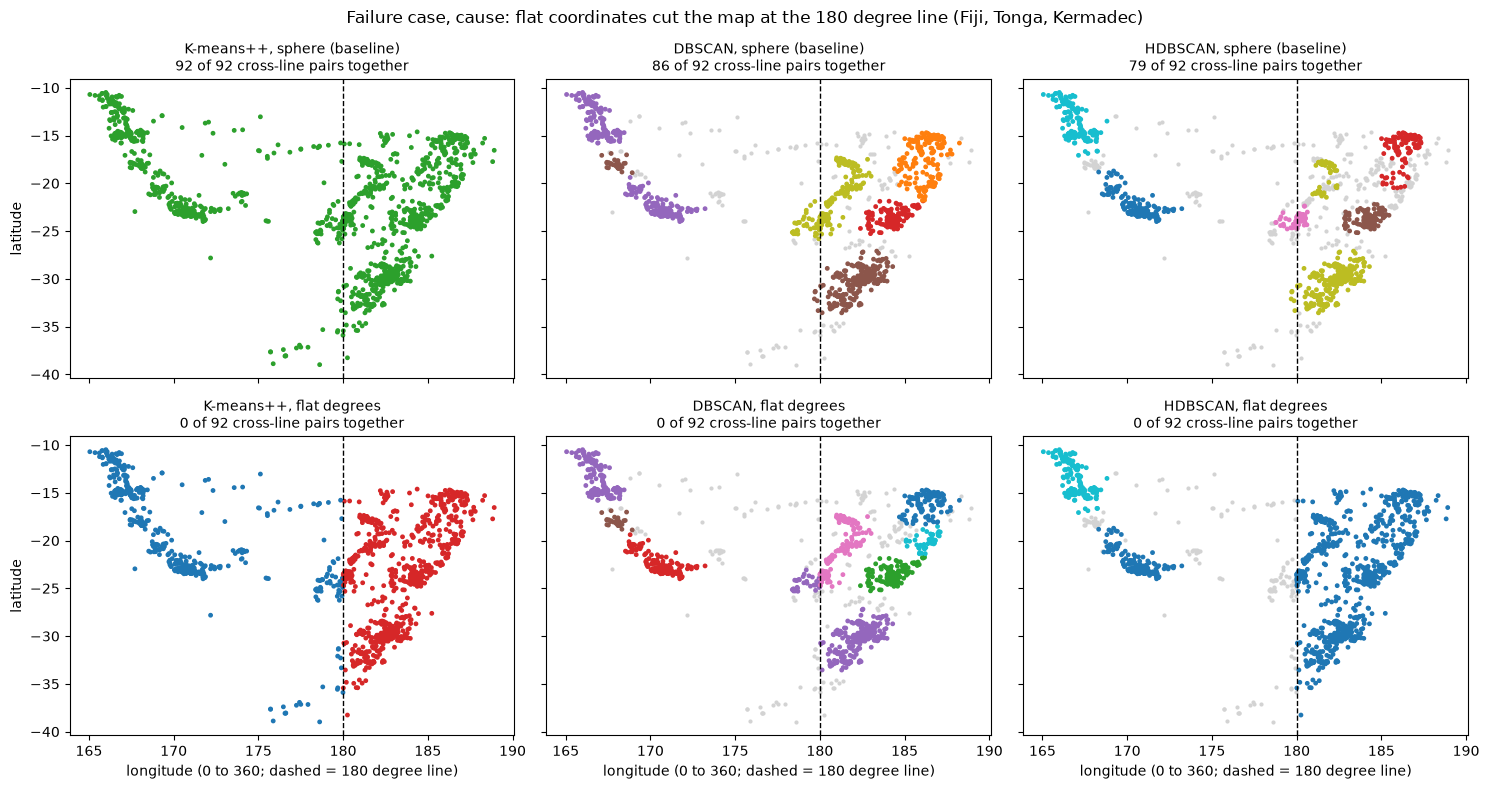

In [4]:
def shifted_longitude(lon):
    """Longitude on 0 to 360, so the area around the 180 degree line is drawn in one piece."""
    return np.mod(lon, 360)


area = (events["latitude"].between(-40, -10) & shifted_longitude(events["longitude"]).between(165, 195)).to_numpy()
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for col, method in enumerate(["K-means++", "DBSCAN", "HDBSCAN"]):
    for row, variant in enumerate(["sphere (baseline)", "flat degrees"]):
        ax = axes[row, col]
        labels = distance_labels[(method, variant)][area]
        x, y = shifted_longitude(events.loc[area, "longitude"]), events.loc[area, "latitude"]
        noise = labels == NOISE_LABEL
        ax.scatter(x[noise], y[noise], s=4, color="lightgrey")
        ax.scatter(x[~noise], y[~noise], s=6, color=cluster_colours(labels[~noise]))
        ax.axvline(180, color="black", linestyle="--", linewidth=1)
        pairs = distance_ablation.set_index(["method", "distance"]).loc[(method, variant)]
        ax.set_title(f"{method}, {variant}\n{int(pairs['pairs_same_cluster'])} of {int(pairs['cross_line_pairs'])} cross-line pairs together", fontsize=10)
    axes[1, col].set(xlabel="longitude (0 to 360; dashed = 180 degree line)")
for ax in axes[:, 0]:
    ax.set(ylabel="latitude")
fig.suptitle("Failure case, cause: flat coordinates cut the map at the 180 degree line (Fiji, Tonga, Kermadec)")
plt.tight_layout()
fig.savefig(FIGURES / "failure_180_degree_line.png", dpi=150)
plt.show()

**Observations**

- **Flat degrees split every cross-line pair.** There are 92 pairs of earthquakes within 50 km of each other on opposite sides of the 180 degree line. On the sphere, K-means puts all 92 in the same cluster, DBSCAN 86 and HDBSCAN 79 (the other pairs have at least one earthquake marked as noise). On flat degrees all three methods put **0 of 92** together.
- **K-means is changed everywhere, not only at the line:** silhouette falls from 0.528 to 0.404, Davies-Bouldin rises from 0.738 to 0.996, the largest cluster grows from 31.0% to 39.5%, and the labels agree with the baseline at only ARI 0.557. In the figure, flat K-means cuts the Fiji, Tonga and Kermadec group exactly along the line.
- **DBSCAN hides the failure in its global numbers:** 43 clusters instead of 41, noise 42.2% instead of 40.4%, silhouette 0.701 instead of 0.703, ARI 0.948. Only the clusters that cross the line are split, which the cross-line count shows and the silhouette does not.
- **HDBSCAN merges and discards:** 23 clusters instead of 28, largest cluster 11.6% instead of 7.5%, silhouette 0.721 instead of 0.757, ARI 0.784. In the figure the whole area east of the line becomes one cluster and the earthquakes just west of it become noise, so no cross-line pair has both earthquakes clustered.
- **Conclusion:** the spherical representation chosen in the EDA is a correctness fix for all three methods. Global metrics understate the damage for DBSCAN; a check aimed at the known problem (cross-line pairs) is needed to see it.

## 3. Time window: each half of the year

EDA section 9 found stable belts but aftershock sequences that change the density of some patches between
January to June and July to December. Each half is clustered on its own with the baseline settings and
compared with the full-year labels on the same earthquakes. Halving the data also halves the density, so
two random halves (seed 0) of the same sizes are run as a control.

In [5]:
months = pd.to_datetime(events["time"]).dt.month.to_numpy()
order = np.random.default_rng(SEED).permutation(len(events))
random_half = np.zeros(len(events), dtype=bool)
random_half[order[: int((months <= 6).sum())]] = True
subsets = {
    "Jan-Jun": months <= 6,
    "Jul-Dec": months > 6,
    "random half A (control)": random_half,
    "random half B (control)": ~random_half,
}
rows = []
for name, mask in subsets.items():
    part = fit_baseline(degrees[mask])
    for method, labels in part.items():
        rows.append({"subset": name, "method": method, "earthquakes": int(mask.sum()), **scores(mask, labels),
                     "ARI vs full-year labels": adjusted_rand_score(baseline[method][mask], labels)})
time_ablation = pd.DataFrame(rows)
time_ablation.to_csv(RESULTS / "ablation_time_window.csv", index=False)
time_ablation.pivot(index="subset", columns="method", values=["n_clusters", "noise_fraction", "silhouette", "ARI vs full-year labels"])

n_clusters                   noise_fraction                   silhouette                   ARI vs full-year labels                  
method                      DBSCAN HDBSCAN K-means++         DBSCAN HDBSCAN K-means++     DBSCAN HDBSCAN K-means++                  DBSCAN HDBSCAN K-means++
subset                                                                                                                                                      
Jan-Jun                       25.0    14.0       6.0          0.580   0.356       0.0      0.789   0.722     0.563                   0.616   0.414     0.963
Jul-Dec                       25.0    14.0       6.0          0.559   0.274       0.0      0.860   0.710     0.504                   0.550   0.472     0.829
random half A (control)       21.0    16.0       6.0          0.582   0.431       0.0      0.836   0.792     0.521                   0.551   0.505     0.968
random half B (control)       22.0    19.0       6.0          0.590   0.321       0.0      0.836   0.728     0.530                   0.527   0.544     0.994

**Observations**

- **DBSCAN changes as much with a random half as with a time half.** Each time half gives 25 clusters with 55.9% to 58.0% noise and agrees with the full-year labels at ARI 0.550 to 0.616; the random halves give 21 to 22 clusters, 58.2% to 59.0% noise and ARI 0.527 to 0.551. The change comes from halving the density: eps stays at 101.8 km and `min_samples` at 20, so fewer earthquakes are core points and noise rises from 40.4% to about 58%.
- **HDBSCAN time halves agree slightly less with the full year than random halves:** ARI 0.414 to 0.472 against 0.505 to 0.544, with 14 clusters in each time half against 16 to 19. Noise is 27.4% to 35.6% (time halves) and 32.1% to 43.1% (random halves).
- **K-means is robust except in the second half:** January to June agrees with the full year at ARI 0.963, close to the random halves (0.968 and 0.994), but July to December only at 0.829. This is consistent with EDA section 9, where the Philippines cell grew from 66 earthquakes in the first half to 534 in the second, pulling a centre towards it.
- **Implication:** with parameters fixed, the density methods' labels depend strongly on how many earthquakes there are (ARI 0.41 to 0.62 for any half). `min_samples` and `min_cluster_size` are counts, so they have to be re-chosen when the data size changes. The time window itself matters most for K-means, through large aftershock sequences.

## 4. Minimum magnitude 5.0

EDA section 10 kept magnitude 4.5 and above and listed 5.0 as an ablation. The baseline settings are kept
(including `min_cluster_size` and `min_samples`, which were chosen for about 7,600 earthquakes), and a
random subset of the same size (seed 0) is run as a control.

In [6]:
strong = (events["mag"] >= 5.0).to_numpy()
control = np.zeros(len(events), dtype=bool)
control[np.random.default_rng(SEED).choice(len(events), int(strong.sum()), replace=False)] = True
rows = []
for name, mask in {"all magnitude 4.5+ (baseline)": everything, "magnitude 5.0+": strong, "random subset of same size (control)": control}.items():
    part = baseline if mask is everything else fit_baseline(degrees[mask])
    for method, labels in part.items():
        rows.append({"subset": name, "method": method, "earthquakes": int(mask.sum()), **scores(mask, labels),
                     "ARI vs full labels": adjusted_rand_score(baseline[method][mask], labels)})
magnitude_ablation = pd.DataFrame(rows)
magnitude_ablation.to_csv(RESULTS / "ablation_min_magnitude.csv", index=False)
magnitude_ablation.pivot(index="subset", columns="method", values=["n_clusters", "noise_fraction", "largest_cluster_share", "silhouette", "ARI vs full labels"])

n_clusters                   noise_fraction                   largest_cluster_share                   silhouette                   ARI vs full labels                  
method                                   DBSCAN HDBSCAN K-means++         DBSCAN HDBSCAN K-means++                DBSCAN HDBSCAN K-means++     DBSCAN HDBSCAN K-means++             DBSCAN HDBSCAN K-means++
subset                                                                                                                                                                                                      
all magnitude 4.5+ (baseline)              41.0    28.0       6.0          0.404   0.307       0.0                 0.118   0.075     0.310      0.703   0.757     0.528              1.000   1.000     1.000
magnitude 5.0+                             12.0     8.0       6.0          0.712   0.329       0.0                 0.069   0.142     0.297      0.898   0.682     0.517              0.343   0.322     0.966
random subset of same size (control)       12.0     8.0       6.0          0.696   0.317       0.0                 0.085   0.170     0.310      0.899   0.675     0.539              0.315   0.303     0.977

**Observations**

- **Magnitude 5.0+ behaves like a random subset of the same size (1,780 earthquakes):**
  - DBSCAN: 12 clusters in both; noise 71.2% vs 69.6%; ARI vs full labels 0.343 vs 0.315;
  - HDBSCAN: 8 clusters in both; noise 32.9% vs 31.7%; ARI 0.322 vs 0.303;
  - K-means: ARI 0.966 vs 0.977; silhouette 0.517 vs 0.539.
- So removing smaller earthquakes changes the results only by leaving fewer of them, not by removing a particular group: at this scale, magnitude 5.0+ earthquakes occur in the same places as smaller ones.
- **Fewer earthquakes break the density settings:** DBSCAN noise rises from 40.4% to 71.2%, above the 50% cap used for selection. HDBSCAN finds 8 clusters instead of 28, with the largest holding 14.2% instead of 7.5%. DBSCAN's silhouette rises to 0.898 only because it is computed on the 28.8% of earthquakes that remain clustered.
- **Decision:** the EDA choice of magnitude 4.5 and above stands; a 5.0 cutoff gives no benefit.

## 5. Success and failure cases

**Density (DBSCAN vs HDBSCAN).** Two areas with different density: the Americas (sparse, long belts) and
the south-west Pacific from the Solomon Islands to Tonga (very dense). Baseline labels from section 1.

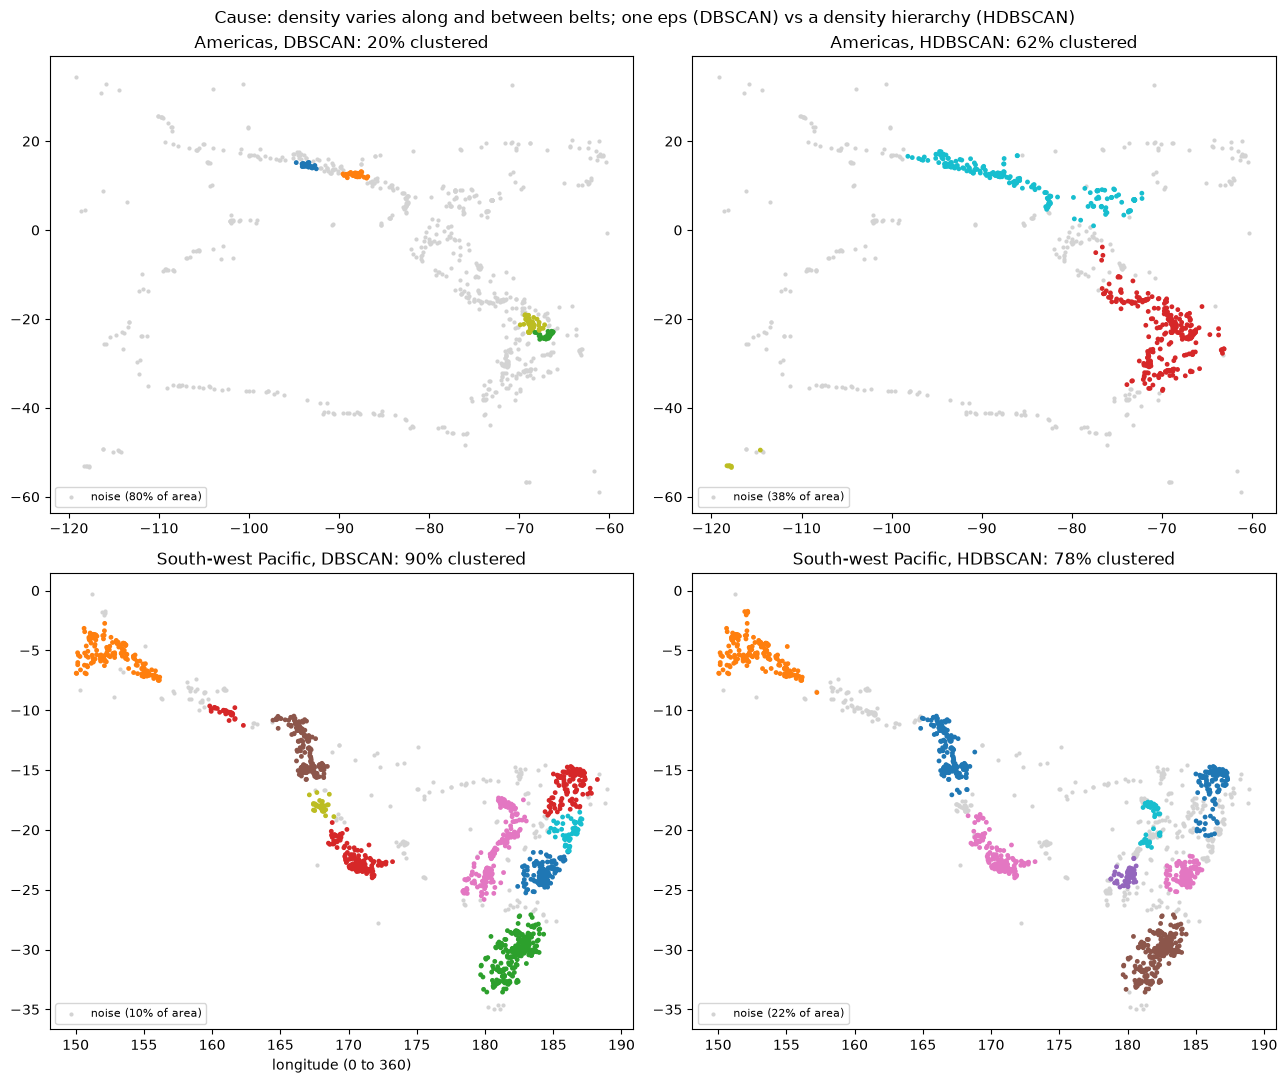

In [7]:
def draw(ax, mask, labels, title, shift=False):
    lon = events.loc[mask, "longitude"].to_numpy()
    x = shifted_longitude(lon) if shift else lon
    y = events.loc[mask, "latitude"].to_numpy()
    part = labels[mask]
    noise = part == NOISE_LABEL
    ax.scatter(x[noise], y[noise], s=4, color="lightgrey", label=f"noise ({noise.mean():.0%} of area)")
    ax.scatter(x[~noise], y[~noise], s=6, color=cluster_colours(part[~noise]))
    ax.set(title=title)
    ax.legend(loc="lower left", fontsize=8)


lat, lon = events["latitude"], events["longitude"]
americas = (lon.between(-120, -60) & lat.between(-60, 35)).to_numpy()
southwest_pacific = (lat.between(-35, 0) & shifted_longitude(lon).between(150, 190)).to_numpy()
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for col, method in enumerate(["DBSCAN", "HDBSCAN"]):
    labels = relabel_by_size(baseline[method])
    draw(axes[0, col], americas, labels, f"Americas, {method}: {(labels[americas] != NOISE_LABEL).mean():.0%} clustered")
    draw(axes[1, col], southwest_pacific, labels, f"South-west Pacific, {method}: {(labels[southwest_pacific] != NOISE_LABEL).mean():.0%} clustered", shift=True)
axes[1, 0].set(xlabel="longitude (0 to 360)")
fig.suptitle("Cause: density varies along and between belts; one eps (DBSCAN) vs a density hierarchy (HDBSCAN)")
plt.tight_layout()
fig.savefig(FIGURES / "case_density_dbscan_vs_hdbscan.png", dpi=150)
plt.show()

**Shape (K-means).** K-means assumes compact, roughly round clusters around a centre. The K-means
cluster containing Turkey is drawn with the HDBSCAN clusters inside it, and the distances between the
centres of those HDBSCAN clusters are measured.

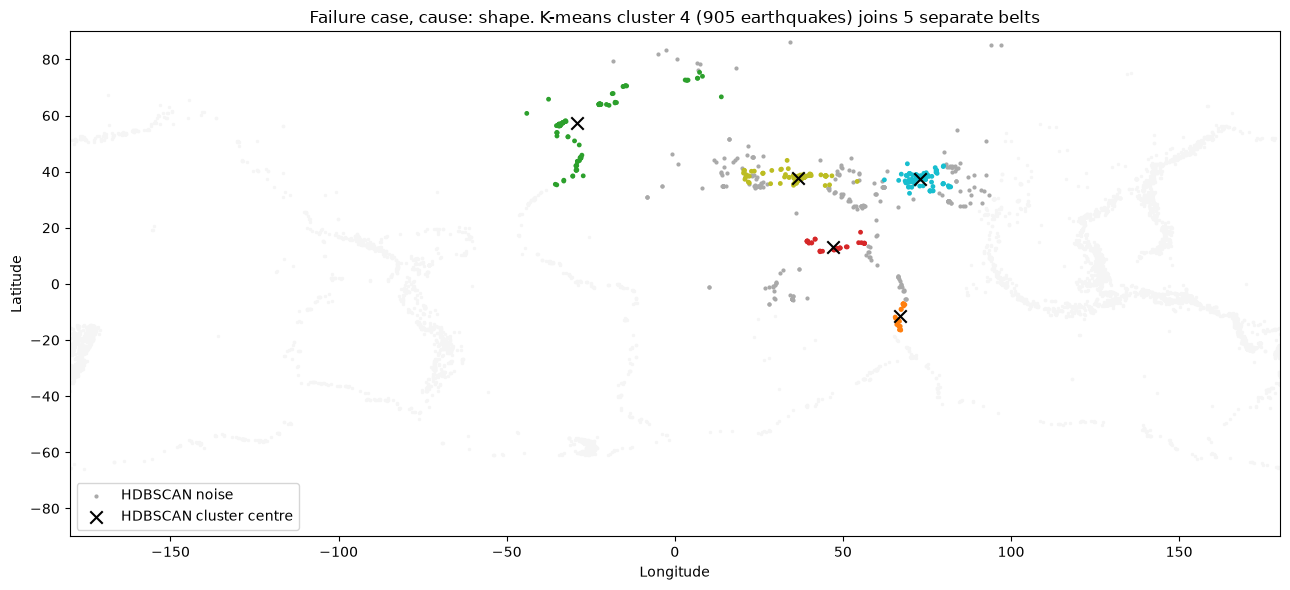

distance between HDBSCAN cluster centres inside K-means cluster 4: min 2932 km, max 11449 km


,events,centre latitude,centre longitude,median km to centre,top regions
0,246,37.914,36.506,129.531,"Turkey (184), Central Turkey (17), Greece (12)"
1,183,57.237,-29.176,830.584,"Reykjanes Ridge (86), Iceland (44), northern Mid-Atlantic Ridge (24)"
2,113,37.314,73.037,239.368,"Afghanistan (39), Tajikistan (34), China (19)"
3,28,-11.454,67.032,399.811,"Mid-Indian Ridge (23), Chagos Archipelago region (5)"
4,67,13.310,47.177,152.997,"Somalia (40), Eritrea (9), Owen Fracture Zone region (5)"


In [8]:
kmeans_labels = relabel_by_size(baseline["K-means++"])
hdbscan_labels = relabel_by_size(baseline["HDBSCAN"])
regions = region_from_place(events["place"])
turkey_cluster = int(pd.Series(kmeans_labels[(regions == "Turkey").to_numpy()]).mode()[0])
inside = kmeans_labels == turkey_cluster

fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(lon[~inside], lat[~inside], s=2, color="whitesmoke")
noise = inside & (hdbscan_labels == NOISE_LABEL)
ax.scatter(lon[noise], lat[noise], s=4, color="darkgrey", label="HDBSCAN noise")
kept = inside & (hdbscan_labels != NOISE_LABEL)
ax.scatter(lon[kept], lat[kept], s=6, color=cluster_colours(hdbscan_labels[kept]))
summary = cluster_summary(events[inside].reset_index(drop=True), hdbscan_labels[inside])
summary = summary[summary["events"] >= 10]
ax.scatter(summary["centre longitude"], summary["centre latitude"], marker="x", s=80, color="black", label="HDBSCAN cluster centre")
ax.set(xlim=(-180, 180), ylim=(-90, 90), xlabel="Longitude", ylabel="Latitude",
       title=f"Failure case, cause: shape. K-means cluster {turkey_cluster} ({inside.sum()} earthquakes) joins {len(summary)} separate belts")
ax.legend(loc="lower left")
plt.tight_layout()
fig.savefig(FIGURES / "case_kmeans_merges_belts.png", dpi=150)
plt.show()

centres = summary[["centre latitude", "centre longitude"]].to_numpy()
gaps = haversine_km(centres[:, None, 0], centres[:, None, 1], centres[None, :, 0], centres[None, :, 1])
print(f"distance between HDBSCAN cluster centres inside K-means cluster {turkey_cluster}: "
      f"min {gaps[np.triu_indices(len(centres), 1)].min():.0f} km, max {gaps.max():.0f} km")
summary[["events", "centre latitude", "centre longitude", "median km to centre", "top regions"]]

**Observations**

**Density, DBSCAN vs HDBSCAN** (baseline settings):
- **Americas: success for HDBSCAN, failure for DBSCAN.** HDBSCAN clusters 62% of the area's earthquakes and keeps the Mexico to Panama belt and the Chile and Argentina belt as long clusters. DBSCAN clusters 20%: four short segments, with the rest as noise.
- **South-west Pacific: DBSCAN clusters more.** DBSCAN clusters 90% of the area and splits it into compact groups along each arc; HDBSCAN clusters 78% and leaves the earthquakes between its dense cores as noise.
- **Cause: density varies between belts.** An eps of 101.8 km suits the dense arcs of the western Pacific but not the sparser belts of the Americas; HDBSCAN picks a density level per cluster, which recovers the sparse belts but trims the edges of very dense cores.

**Shape, K-means:**
- **Failure.** K-means cluster 4 (905 earthquakes) contains 5 HDBSCAN clusters of at least 10 earthquakes: Turkey (246), the Reykjanes Ridge and Iceland (183), Afghanistan and Tajikistan (113), Somalia and Eritrea (67) and the Mid-Indian Ridge (28). Their centres are 2,932 to 11,449 km apart, and most of the cluster's other earthquakes are HDBSCAN noise.
- **Cause: shape.** K-means assigns each earthquake to the nearest of 6 centres, so it assumes compact groups around a centre. Earthquakes lie on long, thin belts with empty space between them, and K-means joins whatever belts share a nearest centre, however large the gaps.

**Distance representation** (section 2): flat coordinates split all 92 cross-line pairs for every method. Cause: scale, since flat degrees make the 180 degree line look like the far side of the map.

## 6. Scalability

Runtime against the number of earthquakes: random subsets of 500, 1,000, 2,000 and 4,000 earthquakes and
the full 7,643, three subsets per size (seeds 0 to 2), baseline settings. One untimed warm-up fit of each
method runs first. The slope of log(seconds) against log(n) estimates how runtime grows (1 = linear, 2 = quadratic).
Runtimes vary between runs; the slopes and the ordering are the result, not the exact seconds.

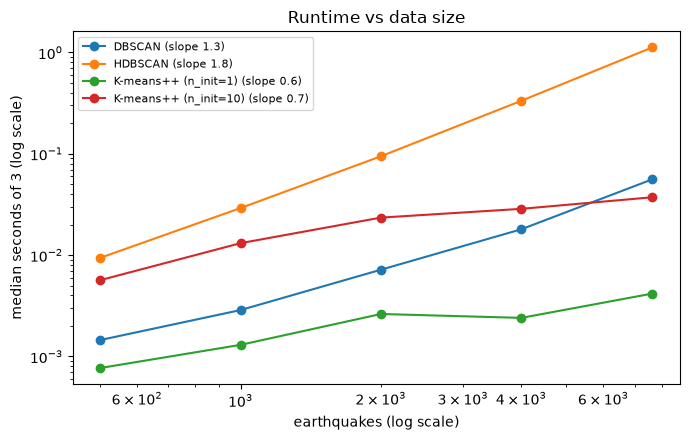

method,DBSCAN,HDBSCAN,K-means++ (n_init=1),K-means++ (n_init=10)
n,,,,
500,0.001,0.009,7.695e-04,0.006
1000,0.003,0.029,1.303e-03,0.013
2000,0.007,0.095,2.627e-03,0.023
4000,0.018,0.334,2.404e-03,0.029
7643,0.056,1.124,4.177e-03,0.037


,log-log slope
DBSCAN,1.335
HDBSCAN,1.754
K-means++ (n_init=1),0.584
K-means++ (n_init=10),0.667


In [9]:
timed_methods = {
    "K-means++ (n_init=10)": (lambda: KMeans(CHOSEN_K, n_init=10, random_state=SEED), U),
    "K-means++ (n_init=1)": (lambda: methods.kmeans_plus_plus(CHOSEN_K, seed=SEED), U),
    "DBSCAN": (lambda: methods.dbscan(EPS_KM, MIN_SAMPLES), R),
    "HDBSCAN": (lambda: methods.hdbscan(MIN_CLUSTER_SIZE, HDBSCAN_MIN_SAMPLES), R),
}
for make, X in timed_methods.values():
    make().fit_predict(X[:1000])

SIZES = (500, 1000, 2000, 4000, len(events))
rows = []
for n in SIZES:
    for seed in range(3):
        subset = np.random.default_rng(seed).choice(len(events), n, replace=False)
        for method, (make, X) in timed_methods.items():
            _, seconds = timed_fit_predict(make(), X[subset])
            rows.append({"n": n, "seed": seed, "method": method, "seconds": seconds})
scaling = pd.DataFrame(rows)
scaling.to_csv(RESULTS / "scalability.csv", index=False)

median_seconds = scaling.groupby(["method", "n"])["seconds"].median().unstack("method")
slopes = {method: np.polyfit(np.log(median_seconds.index), np.log(median_seconds[method]), 1)[0] for method in median_seconds}
fig, ax = plt.subplots(figsize=(7, 4.5))
for method in median_seconds:
    ax.plot(median_seconds.index, median_seconds[method], marker="o", label=f"{method} (slope {slopes[method]:.1f})")
ax.set(xscale="log", yscale="log", xlabel="earthquakes (log scale)", ylabel="median seconds of 3 (log scale)", title="Runtime vs data size")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES / "scalability.png", dpi=150)
plt.show()
display(median_seconds)
pd.Series(slopes, name="log-log slope").to_frame()

**Observations**

- **HDBSCAN is the slowest at every size**: about 1 s on all 7,643 earthquakes, roughly 20 times DBSCAN. Its runtime grows fastest (log-log slope about 1.7 to 1.8 across runs), so 10 times more earthquakes would take about 50 to 60 times longer.
- **DBSCAN grows faster than linearly** (slope about 1.3 to 1.4). Its eps is fixed in km, so with more earthquakes each neighbourhood contains more points to check.
- **K-means++ shows a slope below 1** (about 0.5 to 0.7). At these sizes a fixed cost per fit dominates, so this range cannot show how it grows on larger data; each K-means iteration is linear in the number of points.
- DBSCAN is faster than K-means++ with 10 starts at small sizes and similar at the full size.
- **At 7,643 earthquakes every method takes about a second or less**, so runtime is not what decides between them on this dataset; the growth rates matter only for much larger catalogues.

## 7. Across datasets: comparison and key factors

The other datasets are analysed in `../sc4020-clustering`. Their result CSVs are read here if present.
Caveats: earthquake silhouette uses great-circle distance, LTA silhouette uses Euclidean distance on
usage profiles, so silhouette values are comparable within a dataset, not across datasets. The synthetic
comparison uses fixed settings (DBSCAN eps 0.3, HDBSCAN `min_cluster_size` 15), not tuned ones.

In [10]:
OTHER = ROOT.parent / "sc4020-clustering" / "results"
columns = ["dataset", "method", "setting", "n_clusters", "noise_fraction", "largest_cluster_share", "silhouette", "null_silhouette", "davies_bouldin", "seconds"]
frames = [pd.read_csv(RESULTS / "method_comparison.csv").assign(dataset="earthquakes")]
lta_path = OTHER / "lta" / "method_comparison.csv"
if lta_path.exists():
    lta = pd.read_csv(lta_path).rename(columns={"silhouette_null": "null_silhouette"})
    frames.append(lta.assign(dataset="LTA " + lta["kind"].str.lower()))
else:
    print(f"not found: {lta_path}")
cross_dataset = pd.concat(frames, ignore_index=True)[columns]
cross_dataset.to_csv(RESULTS / "cross_dataset_comparison.csv", index=False)
display(cross_dataset)

synthetic_path = OTHER / "synthetic" / "synthetic_comparison.csv"
if synthetic_path.exists():
    display(Markdown("**Synthetic datasets: ARI against the true labels** (fixed settings)"))
    display(pd.read_csv(synthetic_path).pivot(index="dataset", columns="method", values="ari"))
else:
    print(f"not found: {synthetic_path}")

,dataset,method,setting,n_clusters,noise_fraction,largest_cluster_share,silhouette,null_silhouette,davies_bouldin,seconds
0,earthquakes,K-means (random),"K=6, n_init=1",6.0,0.000,0.443,0.525,0.389,0.800,4.304e-03
1,earthquakes,K-means++,"K=6, n_init=1",6.0,0.000,0.310,0.528,0.391,0.738,5.043e-03
2,earthquakes,DBSCAN,"eps=101.8 km, min_samples=20",41.0,0.404,0.118,0.703,NaN,0.351,5.148e-02
3,earthquakes,HDBSCAN,"min_cluster_size=50, min_samples=default",28.0,0.307,0.075,0.757,0.320,0.329,1.081e+00
4,LTA train,K-means (random),"K=4, n_init=1",4.0,0.000,0.486,0.260,0.067,1.313,1.539e-03
5,LTA train,K-means++,"K=4, n_init=1",4.0,0.000,0.481,0.257,0.066,1.332,7.653e-04
6,LTA train,DBSCAN,"eps=0.0686 (p75), min_samples=5",2.0,0.135,0.816,0.487,NaN,0.595,1.226e-03
7,LTA train,HDBSCAN,"min_cluster_size=5, min_samples=default",2.0,0.416,0.551,0.497,NaN,0.533,3.156e-03
8,LTA bus,K-means (random),"K=5, n_init=1",5.0,0.000,0.299,0.204,0.082,1.483,1.490e-02
9,LTA bus,K-means++,"K=5, n_init=1",5.0,0.000,0.299,0.204,0.133,1.483,1.793e-02


**Synthetic datasets: ARI against the true labels** (fixed settings)

method,DBSCAN,HDBSCAN,K-means (random),K-means++
dataset,,,,
anisotropic,0.000e+00,0.972,8.957e-01,8.975e-01
blobs,1.608e-05,0.417,8.146e-01,8.146e-01
circles,1.000e+00,1.000,-6.676e-04,-6.515e-04
moons,1.000e+00,1.000,4.934e-01,4.934e-01
varied_density,1.524e-02,0.755,7.149e-01,7.149e-01


**Observations**

- **Density methods work only where screening found density structure.**
  - Earthquakes (Stage 0: HDBSCAN noise 22.7% vs 59% to 66% for the null): DBSCAN and HDBSCAN find 41 and 28 clusters, with 40.4% and 30.7% noise and no cluster above 11.8% of earthquakes.
  - LTA train (Stage 0: HDBSCAN 42% noise, from `../AGENTS.md`): both find only 2 clusters, with one holding 81.6% (DBSCAN) or 55.1% (HDBSCAN) of stations.
  - LTA bus (Stage 0: HDBSCAN 100% noise): HDBSCAN has no setting with 2 or more clusters and at most 50% noise; DBSCAN's one valid setting has 2 clusters, one holding 79.5% of stops.
- **K-means beats its null on every dataset:** silhouette 0.528 vs 0.391 (earthquakes), 0.257 vs 0.066 (LTA train) and 0.204 vs 0.133 (LTA bus, K-means++). It is the only method that describes every station in the LTA data.
- **Synthetic data (true labels, fixed settings):**
  - K-means fails on non-convex shapes: ARI about 0 on circles and 0.493 on moons, but 0.815 on blobs and 0.896 to 0.898 on anisotropic blobs;
  - HDBSCAN reaches 1.000 on moons and circles, 0.972 on anisotropic blobs and 0.755 on varied density, but only 0.417 on blobs;
  - DBSCAN with a fixed eps of 0.3 reaches 1.000 on moons and circles and about 0 on blobs, anisotropic blobs and varied density (0.015).
- **Key factors that change the ranking of methods:**
  1. **Gaps between dense groups** (the Stage 0 HDBSCAN test). With gaps (earthquakes, synthetic shapes) density methods find the structure; without them (LTA profiles) they collapse to one dominant cluster or no valid setting, and K-means is the useful method.
  2. **Shape.** Long or curved groups (earthquake belts, moons, circles) defeat K-means, which assumes compact groups around a centre.
  3. **Varying density.** One eps fails when density differs between groups (synthetic varied density: DBSCAN 0.015 vs HDBSCAN 0.755; Americas: 20% vs 62% clustered); HDBSCAN handles it better, at the cost of trimming dense cores.
- Silhouette values use different distances (great-circle for earthquakes, Euclidean for LTA), so they rank methods within a dataset, not datasets against each other.

## 8. Summary

| Stage 4 item | Result | Evidence |
|---|---|---|
| Comparison and agreement | See `notebooks/clustering.ipynb` section 8; across datasets in section 7 here | `results/method_comparison.csv`, `results/method_agreement.csv`, `results/cross_dataset_comparison.csv` |
| Improvement: spherical distance | Required for all methods: flat degrees put 0 of 92 cross-line pairs together; K-means ARI vs baseline 0.557, silhouette 0.528 to 0.404 | `results/ablation_distance.csv`, `figures/failure_180_degree_line.png` |
| Improvement: DBSCAN to HDBSCAN | HDBSCAN recovers sparse belts (Americas 62% vs 20% clustered) but trims dense cores (south-west Pacific 78% vs 90%) | `figures/case_density_dbscan_vs_hdbscan.png` |
| Robustness: time window | Density labels change as much with random halves as with time halves (ARI 0.41 to 0.62): parameters are counts and depend on data size. K-means drops to ARI 0.829 only for July to December (aftershocks) | `results/ablation_time_window.csv` |
| Ablation: magnitude 5.0+ | Same as a random subset of the same size; no benefit; keep 4.5 | `results/ablation_min_magnitude.csv` |
| Failure case: shape | K-means cluster 4 joins 5 belts whose centres are 2,932 to 11,449 km apart | `figures/case_kmeans_merges_belts.png` |
| Scalability | HDBSCAN slowest (slope about 1.7 to 1.8), DBSCAN about 1.3 to 1.4; all methods about a second or less at 7,643 earthquakes | `results/scalability.csv`, `figures/scalability.png` |
| Key factors | Gaps between dense groups, cluster shape, varying density | Section 7 |